In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(0)
img_size = 32

# Dataset 1: Moving square
N1 = 1000  # number of images
square_side = 8
imgs1 = np.zeros((N1, img_size, img_size), dtype=float)
factors1 = np.zeros((N1, 2))  # columns: [x_position, y_position]
max_pos = img_size - square_side
for i in range(N1):
    x = np.random.randint(0, max_pos+1)
    y = np.random.randint(0, max_pos+1)
    imgs1[i, y:y+square_side, x:x+square_side] = 1.0  # draw white square
    factors1[i] = [x, y]

# Dataset 2: Four shapes with variation in shape, size, x, y
N2 = 5000  # number of images
min_size, max_size = 5, 15  # min/max shape size in pixels
imgs2 = np.zeros((N2, img_size, img_size), dtype=float)
shape_labels = np.zeros(N2, dtype=int)       # 0=square,1=triangle,2=circle,3=oval
other_factors = np.zeros((N2, 3))            # columns: [size, x, y]
for i in range(N2):
    shape = np.random.randint(0, 4)  # random shape type
    size = np.random.randint(min_size, max_size+1)
    # Determine bounding box for shape (width=bw, height=bh)
    if shape == 3:  # oval
        bw = size
        bh = max(1, int(round(size / 2.0)))  # oval's height = half width (aspect ratio 2:1)
    else:
        bw = bh = size  # square, triangle, circle use size×size box
    # Random position such that shape fits in frame
    x = np.random.randint(0, img_size - bw + 1)
    y = np.random.randint(0, img_size - bh + 1)
    # Draw the shape
    if shape == 0:  # square
        imgs2[i, y:y+bh, x:x+bw] = 1.0
    elif shape == 1:  # triangle (right-angle triangle)
        for yy in range(y, y+bh):
            for xx in range(x, x+bw):
                if (yy - y) >= (xx - x):  # fill lower-left half of the box
                    imgs2[i, yy, xx] = 1.0
    elif shape == 2:  # circle
        r = size / 2.0
        cx, cy = x + r, y + r
        for yy in range(y, y+bh):
            for xx in range(x, x+bw):
                if (xx + 0.5 - cx)**2 + (yy + 0.5 - cy)**2 <= r**2:
                    imgs2[i, yy, xx] = 1.0
    elif shape == 3:  # oval (horizontal ellipse)
        a, b = bw / 2.0, bh / 2.0
        cx, cy = x + a, y + b
        for yy in range(y, y+bh):
            for xx in range(x, x+bw):
                if ((xx + 0.5 - cx) / a)**2 + ((yy + 0.5 - cy) / b)**2 <= 1.0:
                    imgs2[i, yy, xx] = 1.0
    shape_labels[i] = shape
    other_factors[i] = [size, x, y]


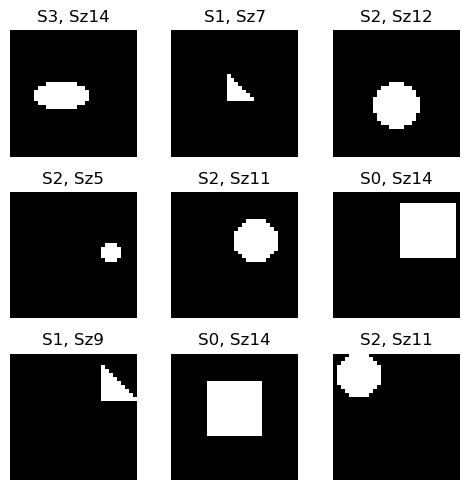

In [5]:
# Show some sample images from Dataset 2
sample_idx = np.random.choice(N2, 9, replace=False)
fig, axes = plt.subplots(3, 3, figsize=(5, 5))
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(imgs2[idx], cmap='gray')
    ax.set_title(f"S{shape_labels[idx]}, Sz{int(other_factors[idx,0])}")
    ax.axis('off')
plt.tight_layout()
plt.show()

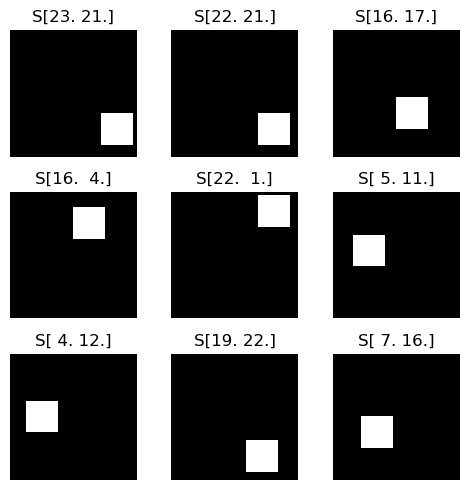

In [6]:
# Show some sample images from Dataset 2
sample_idx = np.random.choice(N1, 9, replace=False)
fig, axes = plt.subplots(3, 3, figsize=(5, 5))
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(imgs1[idx], cmap='gray')
    ax.set_title(f"S{factors1[idx]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [27]:
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.decomposition import FastICA

# Flatten images for manifold learning
X1 = imgs1.reshape(N1, -1)
X2 = imgs2.reshape(N2, -1)

# HLLE on Dataset 1
lle1 = LocallyLinearEmbedding(n_components=2, n_neighbors=20, method='hessian')
Y1_hlle = lle1.fit_transform(X1)  # HLLE 2D embedding of images
# ICA on HLLE embedding (Dataset 1)
ica1 = FastICA(n_components=2, random_state=0)
Z1_hlle_ica = ica1.fit_transform(Y1_hlle)  # independent components

# HLLE on Dataset 2 
lle2 = LocallyLinearEmbedding(n_components=4, n_neighbors=100, method='hessian')
Y2_hlle = lle2.fit_transform(X2)  
# ICA on HLLE embedding (Dataset 2)
ica2 = FastICA(n_components=4, random_state=0)
Z2_hlle_ica = ica2.fit_transform(Y2_hlle)


In [14]:
from sklearn.decomposition import PCA
# PCA and ICA on Dataset 1
pca1 = PCA(n_components=2)
Z1_pca = pca1.fit_transform(X1)
ica1_direct = FastICA(n_components=2, random_state=0)
Z1_ica = ica1_direct.fit_transform(X1)
# PCA and ICA on Dataset 2
pca2 = PCA(n_components=4)
Z2_pca = pca2.fit_transform(X2)
ica2_direct = FastICA(n_components=4, random_state=0)
Z2_ica = ica2_direct.fit_transform(X2)


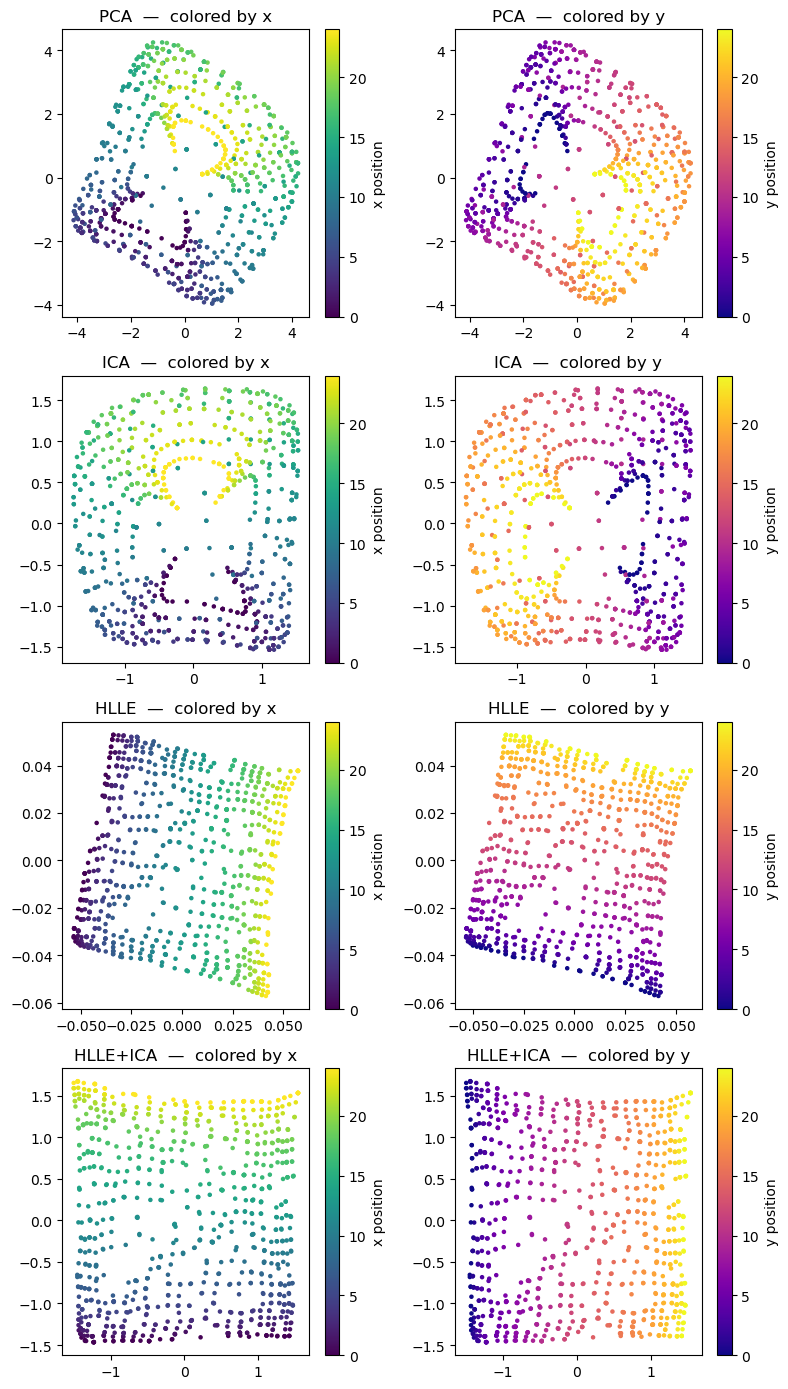

In [15]:
import matplotlib.pyplot as plt


methods = {
    'PCA'       : Z1_pca,
    'ICA'       : Z1_ica,
    'HLLE'      : Y1_hlle,
    'HLLE+ICA'  : Z1_hlle_ica
}

fig, axes = plt.subplots(len(methods), 2, figsize=(8, len(methods)*3.5))
for (name, Z), (ax_x, ax_y) in zip(methods.items(), axes):
    im = ax_x.scatter(Z[:,0], Z[:,1], c=factors1[:,0], cmap='viridis', s=5)
    ax_x.set_title(f'{name}  —  colored by x')
    plt.colorbar(im, ax=ax_x, label='x position')
    
    im = ax_y.scatter(Z[:,0], Z[:,1], c=factors1[:,1], cmap='plasma', s=5)
    ax_y.set_title(f'{name}  —  colored by y')
    plt.colorbar(im, ax=ax_y, label='y position')

plt.tight_layout()
plt.show()


In [ ]:
methods2 = {'PCA': Z2_pca, 'ICA': Z2_ica,
             'HLLE': Y2_hlle, 'HLLE+ICA': Z2_hlle_ica}

factor_names = ['shape', 'size', 'x', 'y']
factors2 = np.concatenate([
    shape_labels.reshape(-1,1),
    other_factors  # (N2,3)
], axis=1)  # (N2,4)

fig, axes = plt.subplots(4, 4, figsize=(12,12))
for i, fname in enumerate(factor_names):
    for j, (mname, Z) in enumerate(methods2.items()):
        ax = axes[i,j]
        sc = ax.scatter(Z[:,3], Z[:,3], c=factors2[:,i], cmap='tab10' if fname=='shape' else 'viridis', s=5)
        ax.set_xticks([]); ax.set_yticks([])
        if i==0: ax.set_title(mname)
        if j==0: ax.set_ylabel(fname)
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [36]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


methods2 = {'PCA': Z2_pca, 'ICA': Z2_ica,
               'HLLE': Y2_hlle, 'HLLE+ICA': Z2_hlle_ica}
factor_names = ['shape', 'size', 'x', 'y']
factors2 = np.concatenate([
       shape_labels.reshape(-1,1),
       other_factors  # (N2,3)
   ], axis=1)

for mname, Z in methods2.items():
    n_dims = Z.shape[1]
    # Prepare a DataFrame to hold correlations: rows=factors, cols=dimensions
    corr_df = pd.DataFrame(index=factor_names,
                           columns=[f"dim_{d}" for d in range(n_dims)],
                           dtype=float)
    # Compute Pearson r for each factor and each latent dimension
    for i, fname in enumerate(factor_names):
        for d in range(n_dims):
            r, _ = pearsonr(Z[:, d], factors2[:, i])
            corr_df.iloc[i, d] = r
    print(f"\n### {mname} Embedding Correlations ###")
    display(corr_df)



### PCA Embedding Correlations ###


,dim_0,dim_1,dim_2,dim_3
shape,-0.055094,-0.060378,-0.228310,-0.018793
size,0.092910,0.086581,0.591809,0.066646
x,0.060272,-0.682795,-0.038285,-0.028331
y,-0.661634,-0.122734,-0.010064,-0.013710



### ICA Embedding Correlations ###


,dim_0,dim_1,dim_2,dim_3
shape,-0.090463,0.211811,0.075212,0.021330
size,0.160627,-0.540093,-0.208142,-0.099917
x,-0.214448,0.296353,-0.329273,-0.479455
y,-0.534978,-0.117621,0.352873,-0.168988



### HLLE Embedding Correlations ###


,dim_0,dim_1,dim_2,dim_3
shape,-0.000982,0.042130,0.272237,-0.005220
size,-0.066119,-0.087720,-0.652823,-0.010866
x,-0.730272,-0.162098,0.221216,0.031507
y,-0.200689,0.744686,0.056574,-0.025942



### HLLE+ICA Embedding Correlations ###


,dim_0,dim_1,dim_2,dim_3
shape,0.002851,0.039926,0.043510,0.269111
size,-0.040044,-0.143358,-0.146221,-0.628353
x,0.082608,-0.507421,-0.471139,0.351043
y,-0.601875,0.282639,-0.344220,0.195146
